In [ ]:
!apt-get update
!apt-get install -y sox libsox-fmt-all libsox-dev


#Raw Audio Analysis

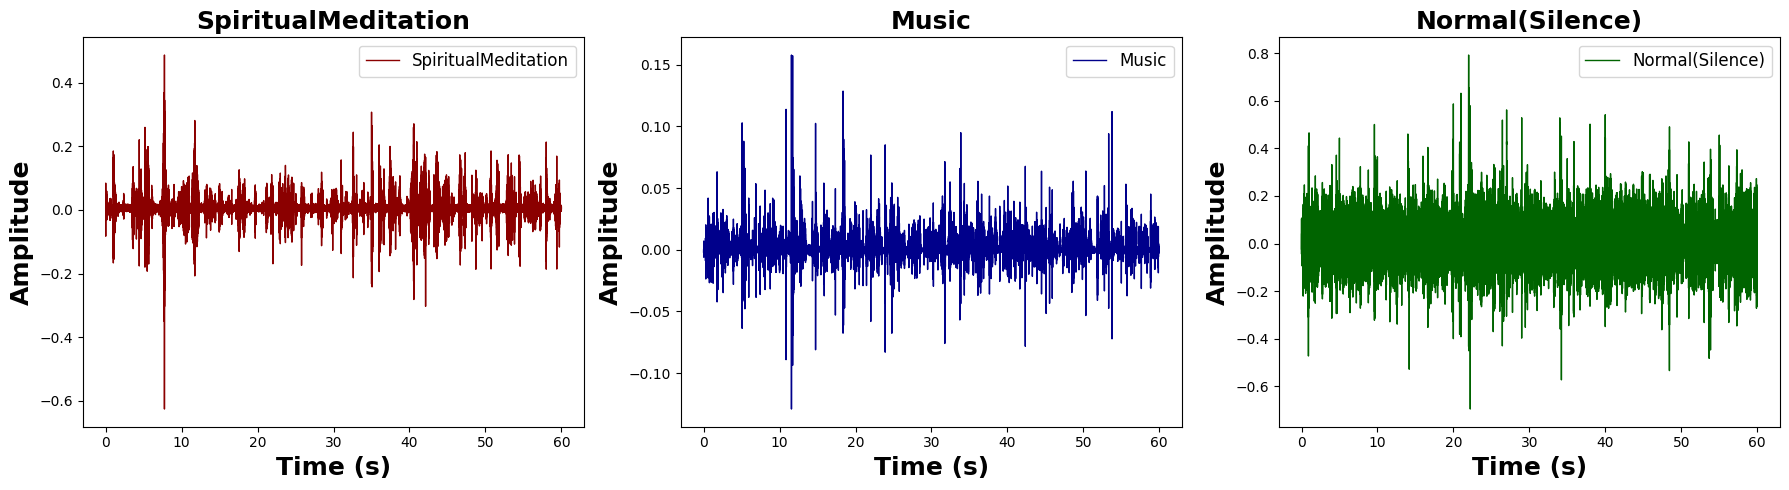

In [1]:
import os
import random
import glob
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# Global settings: Times New Roman.
mpl.rcParams["font.family"] = "Times New Roman"

# Define colors for each class.
class_colors = {
    "SpiritualMeditation": "#8B0000",   # Dark Red
    "Music": "#00008B",                # Dark Blue
    "Normal(Silence)": "#006400"       # Dark Green
}

# Define dataset class.
class RawAudioDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, sample_rate=16000):
        self.sample_rate = sample_rate
        # Expected folder names:
        self.classes = ["SpiritualMeditation", "Music", "Normal(Silence)"]
        self.file_paths = []
        self.labels = []
        for cls in self.classes:
            folder = Path(root_dir) / cls / "Generated-data"  # Updated path to include subfolder
            wav_files = glob.glob(str(folder / '*.wav'))
            if wav_files:
                self.file_paths.extend(wav_files)
                self.labels.extend([cls] * len(wav_files))
            else:
                print(f"Warning: No files found for {cls} in {folder}")
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        waveform, sr = torchaudio.load(file_path)
        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)
        if waveform.dim() == 2:
            waveform = waveform[0].unsqueeze(0)
        label = self.labels[idx]
        return waveform, label


# Main script.
def main():
    # Updated dataset path to SMSAT-generated-data
    root_dir = "/kaggle/input/qmsat-dataset/SMSAT-generated-data/SMSAT-generated-data"
    sample_rate = 16000
    dataset = RawAudioDataset(root_dir, sample_rate=sample_rate)
    
    # Create a figure with 1 row and 3 columns.
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    classes = ["SpiritualMeditation", "Music", "Normal(Silence)"]
    
    for i, cls in enumerate(classes):
        # Get indices for this class.
        indices = [j for j, lab in enumerate(dataset.labels) if lab == cls]
        if not indices:
            axs[i].set_visible(False)
            continue
        sample_idx = random.choice(indices)
        waveform, label = dataset[sample_idx]
        data = waveform.numpy().flatten()
        t = np.linspace(0, len(data) / sample_rate, len(data))
        
        axs[i].plot(t, data, color=class_colors[cls], linewidth=1, label=cls)
        axs[i].set_title(cls, fontsize=18, fontweight='bold')
        axs[i].set_xlabel("Time (s)", fontsize=18, fontweight='bold')
        axs[i].set_ylabel("Amplitude", fontsize=18, fontweight='bold')
        axs[i].legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig("/kaggle/working/all_classes_audio.jpeg", dpi=300, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    main()
